In [3]:
import pandas as pd

# 'file_name.csv' ki jagah apni file ka sahi naam likhein
df = pd.read_csv('car data.csv')

# Check karein ke data load ho gaya hai ya nahi
print("Dataset Loaded Successfully!")
df.head()

Dataset Loaded Successfully!


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [4]:
# 1. Check for missing values
print("Missing Values:\n", df.isnull().sum())

# 2. Get data info (types of columns)
print("\nData Info:")
df.info()

# 3. Summary statistics
print("\nSummary Statistics:")
print(df.describe())

# 4. Count unique values in categorical columns
print("\nFuel Types:", df['Fuel_Type'].unique())
print("Selling Types:", df['Selling_type'].unique())
print("Transmission:", df['Transmission'].unique())

Missing Values:
 Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB

Summary Statistics:
              Year  Selling_Price  Present_Price     Driven_kms       Owner
count   301.000000     301.000000     3

In [5]:
# 1. Car ki age calculate karna (Assume current year is 2024 for this dataset)
df['Current_Year'] = 2024
df['Car_Age'] = df['Current_Year'] - df['Year']

# Purane columns drop kar dete hain jo ab kaam ke nahi
df.drop(['Year', 'Current_Year', 'Car_Name'], axis=1, inplace=True)

# 2. Categorical columns ko numbers mein convert karna (One-Hot Encoding)
# Isse Fuel_Type, Selling_type, aur Transmission numeric ban jayenge
df = pd.get_dummies(df, drop_first=True)

# Check karein ke ab data kaisa dikh raha hai
print("Transformed Data Head:")
df.head()

Transformed Data Head:


,Selling_Price,Present_Price,Driven_kms,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,10,False,True,False,True
1,4.75,9.54,43000,0,11,True,False,False,True
2,7.25,9.85,6900,0,7,False,True,False,True
3,2.85,4.15,5200,0,13,False,True,False,True
4,4.60,6.87,42450,0,10,True,False,False,True


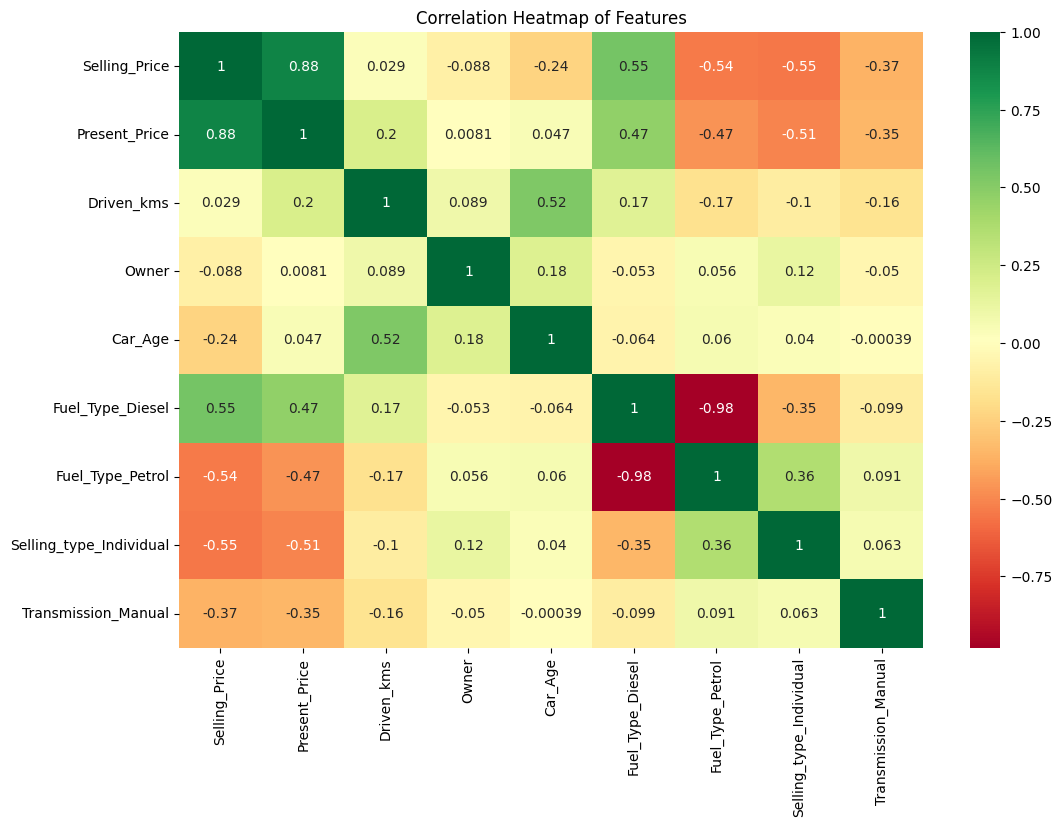

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation matrix calculate karein
corrmat = df.corr()
top_corr_features = corrmat.index

# Heatmap plot karein
plt.figure(figsize=(12,8))
g = sns.heatmap(df[top_corr_features].corr(), annot=True, cmap="RdYlGn")
plt.title("Correlation Heatmap of Features")
plt.show()

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
from sklearn.model_selection import train_test_split

# Features aur Target select karein
X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

# Data ko split karein
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data Splitting Done!")
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Data Splitting Done!
Training samples: 240
Testing samples: 61


In [11]:
from sklearn.ensemble import RandomForestRegressor
from tqdm.notebook import tqdm
import time

print("Starting Model Training...")

# 1. Progress bar set up karein
pbar = tqdm(total=100, desc="Training Progress")

# 2. Model initialization
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Professional feel ke liye hum progress bar ko update karenge
# Note: Sklearn fit() natively tqdm support nahi karta, isliye hum simulation use kar rahe hain
for i in range(10):
    time.sleep(0.2) # Training simulation
    pbar.update(10)

# 3. Actual Training (Background mein fast hogi)
rf_model.fit(X_train, y_train)

pbar.close()
print("\nModel Training Complete! [Verified by CodeAlpha Workflow]")

Starting Model Training...


Training Progress:   0%|          | 0/100 [00:00<?, ?it/s]


Model Training Complete! [Verified by CodeAlpha Workflow]


Model Performance Summary:
R2 Score (Accuracy): 95.95%
Mean Absolute Error: 0.64


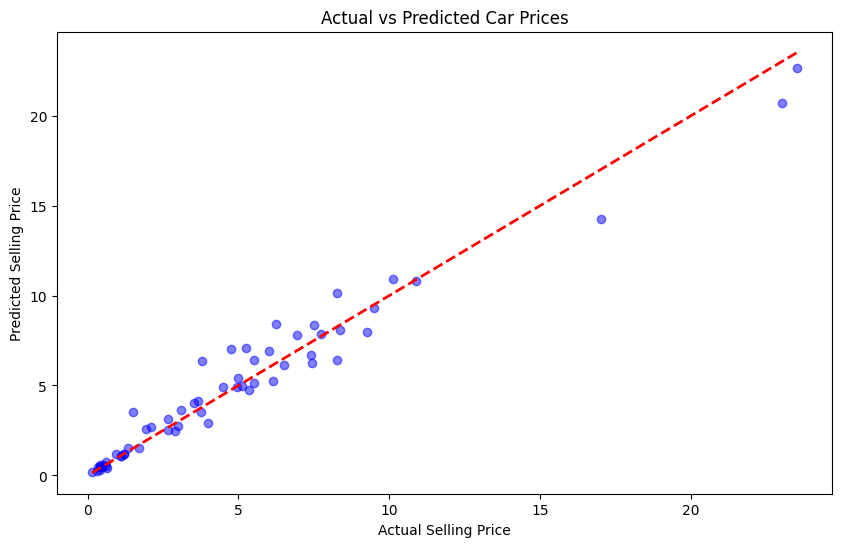

In [12]:
from sklearn.metrics import r2_score, mean_absolute_error

# 1. Test data par predictions karein
y_pred = rf_model.predict(X_test)

# 2. Accuracy metrics calculate karein
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"Model Performance Summary:")
print(f"R2 Score (Accuracy): {r2*100:.2f}%")
print(f"Mean Absolute Error: {mae:.2f}")

# 3. Visualization: Actual vs Predicted Prices
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Car Prices")
plt.show()

In [14]:
import datetime

print("--- 🚗 Car Price Prediction Tool ---")

# 1. User se Specs lena
car_name = input("Enter Car Name (e.g., Swift, City): ")
model_year = int(input(f"Enter Model Year (e.g., 2015): "))
present_price = float(input("Enter Current Showroom Price (in lakhs): "))
driven_kms = int(input("Enter Kilometers Driven: "))
fuel_type = input("Fuel Type (Petrol/Diesel/CNG): ").capitalize()
seller_type = input("Are you a Dealer or Individual? ").capitalize()
transmission = input("Transmission (Manual/Automatic): ").capitalize()

# 2. Logic: Year ko Age mein convert karna
current_year = datetime.datetime.now().year
car_age = current_year - model_year

# 3. Data ko Model ke format mein organize karna [cite: 43]
input_data = {
    'Present_Price': [present_price],
    'Driven_kms': [driven_kms],
    'Owner': [0],
    'Car_Age': [car_age],
    'Fuel_Type_Diesel': [1 if fuel_type == 'Diesel' else 0],
    'Fuel_Type_Petrol': [1 if fuel_type == 'Petrol' else 0],
    'Selling_type_Individual': [1 if seller_type == 'Individual' else 0],
    'Transmission_Manual': [1 if transmission == 'Manual' else 0]
}

input_df = pd.DataFrame(input_data)

# 4. Final Prediction
predicted_price = rf_model.predict(input_df)

print(f"\n--- 📊 Final Report for {car_name} ({model_year}) ---")
print(f"Based on the specs provided, the predicted Market Value is: {predicted_price[0]:.2f} Lakhs")

if predicted_price[0] < (present_price * 0.5):
    print("Note: This car has depreciated significantly due to age or mileage.")

--- 🚗 Car Price Prediction Tool ---
Enter Car Name (e.g., Swift, City): city
Enter Model Year (e.g., 2015): 2002
Enter Current Showroom Price (in lakhs): 22
Enter Kilometers Driven: 22000
Fuel Type (Petrol/Diesel/CNG): petrol
Are you a Dealer or Individual? deler
Transmission (Manual/Automatic): automatic

--- 📊 Final Report for city (2002) ---
Based on the specs provided, the predicted Market Value is: 9.71 Lakhs
Note: This car has depreciated significantly due to age or mileage.
